## 1. Setup and data loading

In [1]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = "../db.sqlite3"  

conn = sqlite3.connect(DB_PATH)

events_df = pd.read_sql_query("""
    SELECT e.id as event_id, e.title, e.city, e.date, e.created_at, e.organizer_id,
           c.name as category
    FROM events_event e
    JOIN events_category c ON e.category_id = c.id
    WHERE e.status = 'published'
""", conn)

tickets_df = pd.read_sql_query("""
    SELECT event_id, price, quantity_total
    FROM events_tickettype
""", conn)

bookings_df = pd.read_sql_query("""
    SELECT event_id, quantity, status
    FROM events_booking
    WHERE status = 'confirmed'
""", conn)

print(f"Events: {len(events_df)}")
print(f"Ticket types: {len(tickets_df)}")
print(f"Confirmed bookings: {len(bookings_df)}")

Events: 165
Ticket types: 165
Confirmed bookings: 238


## 2. Exploratory data analysis



In [2]:
print(events_df['category'].value_counts())
print()
print(events_df['city'].value_counts().head(10))
print()
print(tickets_df['price'].describe())

category
Music         34
Education     24
Business      21
Sports        20
Gaming        19
Art           17
Health        16
Technology    14
Name: count, dtype: int64

city
Nashville       6
Phoenix         5
Denver          4
Minneapolis     4
Cleveland       4
Saint Paul      4
Atlanta         4
Pittsburgh      4
New Orleans     3
Jacksonville    3
Name: count, dtype: int64

count     165.000000
mean     1076.342909
std       935.096639
min         6.500000
25%       500.000000
50%       807.130000
75%      1371.820000
max      4952.860000
Name: price, dtype: float64


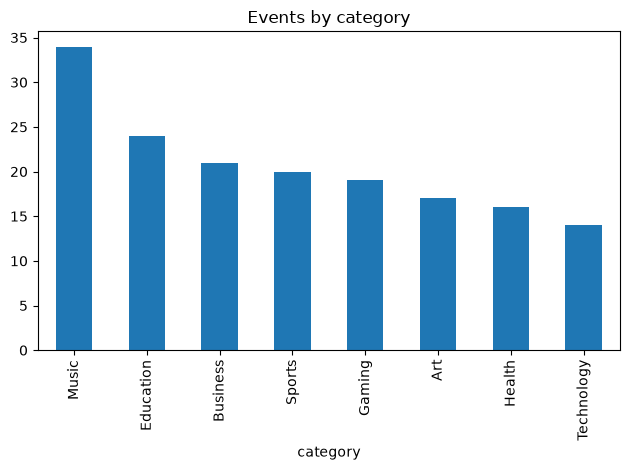

In [3]:
import matplotlib.pyplot as plt

events_df['category'].value_counts().plot(kind='bar', title='Events by category')
plt.tight_layout()
plt.show()

## 3. Feature engineering


In [4]:
tickets_first = tickets_df.groupby('event_id').first().reset_index()
tickets_first = tickets_first[tickets_first['quantity_total'] > 0]  # drop zero-capacity rows

bookings_sum = bookings_df.groupby('event_id')['quantity'].sum().reset_index()
bookings_sum.columns = ['event_id', 'registrations']

df = events_df.merge(tickets_first, on='event_id', how='inner')
df = df.merge(bookings_sum, on='event_id', how='left')
df['registrations'] = df['registrations'].fillna(0)

df['fill_rate'] = df['registrations'] / df['quantity_total']
median_fill = df['fill_rate'].median()
df['is_popular'] = (df['fill_rate'] > median_fill).astype(int)

df['date'] = pd.to_datetime(df['date'])
df['created_at'] = pd.to_datetime(df['created_at'])
df['days_lead_time'] = (df['date'] - df['created_at'].dt.tz_localize(None)).dt.days.clip(lower=0)
df['day_of_week'] = df['date'].dt.weekday
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['month'] = df['date'].dt.month

top_cities = df['city'].value_counts().nlargest(10).index
df['city_bucket'] = df['city'].where(df['city'].isin(top_cities), 'Other')

global_mean = df['fill_rate'].mean()

def track_record(row):
    others = df[(df['organizer_id'] == row['organizer_id']) & (df['event_id'] != row['event_id'])]
    return others['fill_rate'].mean() if len(others) > 0 else global_mean

df['organizer_track_record'] = df.apply(track_record, axis=1)

print(f"Final dataset: {len(df)} events")
print(f"Popular (1) vs not popular (0):")
print(df['is_popular'].value_counts())
df.head()

Final dataset: 165 events
Popular (1) vs not popular (0):
is_popular
0    111
1     54
Name: count, dtype: int64


,event_id,title,city,date,created_at,organizer_id,category,price,quantity_total,registrations,fill_rate,is_popular,days_lead_time,day_of_week,is_weekend,month,city_bucket,organizer_track_record
0,1,Acoustic Sessions at TD Garden,Boston,2026-10-02,2026-09-27 09:47:54.053545,5,Music,3377.42,200,0.0,0.000,0,4,4,0,10,Other,0.013000
1,2,PPL Center Concert Night,Allentown,2026-09-01,2026-09-27 09:47:54.063429,3,Music,612.55,50,3.0,0.060,1,0,1,0,9,Other,0.012917
2,3,Coors Field Championship Night,Denver,2026-11-27,2026-09-27 09:47:54.070706,8,Sports,1187.57,200,0.0,0.000,0,60,4,0,11,Denver,0.015714
3,4,Career Development Seminar,Minneapolis,2026-11-25,2026-09-27 09:47:54.078860,7,Education,223.21,200,1.0,0.005,0,58,2,0,11,Minneapolis,0.013636
4,5,Gallery Opening Night,Phoenix,2026-10-15,2026-09-27 09:47:54.087140,7,Art,589.18,200,1.0,0.005,0,17,3,0,10,Phoenix,0.013636


## 4. Train / test split and baseline comparison



In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC_FEATURES = ['price', 'quantity_total', 'days_lead_time', 'day_of_week', 'is_weekend', 'month', 'organizer_track_record']
CATEGORICAL_FEATURES = ['category', 'city_bucket']

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df['is_popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Train: 132  Test: 33


In [6]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
])

candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, clf in candidates.items():
    pipeline = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    probs = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    results[name] = {'pipeline': pipeline, 'accuracy': acc, 'f1': f1, 'roc_auc': auc}

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.3f}  F1: {f1:.3f}  ROC-AUC: {auc:.3f}")
    print(classification_report(y_test, preds, target_names=['not popular', 'popular']))
    print()

best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"Selected model: {best_name} (ROC-AUC {results[best_name]['roc_auc']:.3f})")

--- LogisticRegression ---
Accuracy: 0.697  F1: 0.286  ROC-AUC: 0.748
              precision    recall  f1-score   support

 not popular       0.70      0.95      0.81        22
     popular       0.67      0.18      0.29        11

    accuracy                           0.70        33
   macro avg       0.68      0.57      0.55        33
weighted avg       0.69      0.70      0.63        33


--- RandomForest ---
Accuracy: 0.667  F1: 0.267  ROC-AUC: 0.684
              precision    recall  f1-score   support

 not popular       0.69      0.91      0.78        22
     popular       0.50      0.18      0.27        11

    accuracy                           0.67        33
   macro avg       0.59      0.55      0.53        33
weighted avg       0.63      0.67      0.61        33


Selected model: LogisticRegression (ROC-AUC 0.748)


## 6. Saving the final model



In [7]:
import joblib

final_pipeline = Pipeline([('prep', preprocessor), ('clf', candidates[best_name])])
final_pipeline.fit(X, y)

joblib.dump({'pipeline': final_pipeline, 'model_name': best_name}, 'popularity_model.joblib')
print("Model saved to popularity_model.joblib")

Model saved to popularity_model.joblib
